# Part II. Simple CNN plus land mask and season

**Author:** Eli Holmes (NOAA), Yifei Hang (UW Varanasi intern 2024), Jiarui Yu (UW Varanasi intern 2023)

[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/ocean-satellite-tools/mind-the-chl-gap/blob/main/book/notebooks/CHL_prediction_CNN_Part_2_gcs.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a>

[colab-link]: https://colab.research.google.com/github/ocean-satellite-tools/mind-the-chl-gap/blob/main/book/notebooks/CHL_prediction_CNN_Part_2_gcs.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/ocean-satellite-tools/mind-the-chl-gap/main/book/notebooks/CHL_prediction_CNN_Part_2_gcs.ipynb

We added the land/ocean mask as an input so the model can learn the land and tell the model not to train on the y (CHL) that is over land since those are not real data. Now let's also add season.

Our new model has spatial variables, seasonal variables, and an ocean mask (categorical).

Our data is in Google Object Storage.

### Variables in the model

| Feature        | Spatial Variation       | Temporal Variation | Notes                             |
|----------------|-------------------------|--------------------|-----------------------------------|
| `sst`          | ✅ Varies by lat/lon     | ✅ Varies by time   | Numeric, normalize                |
| `so`           | ✅ Varies by lat/lon     | ✅ Varies by time   | Numeric, normalize                |
| `sin_time`     | ❌ Same across lat/lon   | ✅ Varies by time   | Cyclical, **do not normalize**    |
| `cos_time`     | ❌ Same across lat/lon   | ✅ Varies by time   | Cyclical, **do not normalize**    |
| `ocean_mask`   | ✅ Varies by lat/lon     | ❌ Static           | Binary (0=land, 1=ocean), do not normalize |
| `y` (response) | ✅ Varies by lat/lon     | ✅ Varies by time   | Numeric, maybe normalize  |


- **`sst` and `so`**: These are our core spatial-temporal features. The CNN will learn spatial filters to extract patterns over ocean and time.
  
- **`sin_time` and `cos_time`**: These introduce seasonality into our model. The CNN can learn seasonally dependent patterns, e.g., chlorophyll blooms in spring. The `sin_time` and `cos_time` features are designed to represent **seasonality** using a **cyclical encoding**. Normalizing these features (e.g., to mean 0, std 1) would **distort their circular geometry** and defeat their intended purpose.

- **`ocean_mask`**: This acts like a location-aware binary filter. It tells the CNN which pixels are land (0) vs ocean (1), which helps avoid learning patterns over invalid/land areas.

- **`y` (response)**: The model trains on this. We have logged it and it is roughly centered near 0. We need to evaluate whether our response has areas with much much higher variance than other areas. If so, we need to do some spatial normalization so our model doesn't only learn the high variance areas.


## Shutdown kernels!

If on the JupyterHub, shutdown kernels before you start in order to not run out of memory.

Kernel > Shutdown All Kernels

## Running the notebook in Colab

Colab is free. Sign in with a Google Account. You get like 100 hours of compute a month.

To get GPU in Colab, go to Edit > Notebook Settings  and select GPU. Most of the libraries you need are loaded with the except of `zarr` and `gcsfs` for connecting to the Google Object Storage for the tutorial dataset. To install that, run this code in Colab. Do this before importing any libraries. 

In [3]:
# Uncomment this line and run if you are in Colab; leave in the !. That is part of the cmd
# !pip install zarr gcsfs --quiet

## Load the libraries

In [1]:
# --- Core data handling libraries ---
import xarray as xr       # for working with labeled multi-dimensional arrays
import numpy as np        # for numerical operations on arrays
import dask.array as da   # for lazy, parallel array operations (used in xarray backends)

# --- Plotting ---
import matplotlib.pyplot as plt  # for creating plots

In [2]:
# --- TensorFlow setup ---
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # suppress TensorFlow log spam (0=all, 3=only errors)

import tensorflow as tf  # main deep learning framework

# --- Keras (part of TensorFlow): building and training neural networks ---
from keras.models import Sequential          # lets us stack layers in a simple linear model
from keras.layers import Conv2D              # 2D convolution layer — finds spatial patterns in image-like data
from keras.layers import BatchNormalization  # stabilizes and speeds up training by normalizing activations
from keras.layers import Dropout             # randomly "drops" neurons during training to reduce overfitting
from keras.callbacks import EarlyStopping    # stops training early if validation loss doesn't improve

2025-06-17 18:26:56.954599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-17 18:26:56.972210: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-17 18:26:56.977615: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## See what machine we are on

In [3]:
# list all the physical devices
physical_devices = tf.config.list_physical_devices()
print("All Physical Devices:", physical_devices)

# list all the available GPUs
gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

# Print infomation for available GPU if there exists any
if gpus:
    for gpu in gpus:
        details = tf.config.experimental.get_device_details(gpu)
        print("GPU Details:", details)
else:
    print("No GPU available")

All Physical Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Details: {'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


## Load data

I created the data for Part I in `Data_Prep_Part_2`. Here I will load.

- sst, so, sin_time, cos_time
- ocean_mask
- y (CHL)

In [4]:
# full dataset 1997 to 2022
dataset = xr.open_dataset(
    "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/cnn_tutorial",
    engine="zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
    consolidated=True
)
dataset

<xarray.Dataset> Size: 5GB
Dimensions:     (time: 9207, lat: 149, lon: 181)
Coordinates:
  * lat         (lat) float32 596B 32.0 31.75 31.5 31.25 ... -4.5 -4.75 -5.0
  * lon         (lon) float32 724B 45.0 45.25 45.5 45.75 ... 89.5 89.75 90.0
  * time        (time) datetime64[ns] 74kB 1997-10-01 1997-10-02 ... 2022-12-31
Data variables:
    cos_time    (time, lat, lon) float32 993MB ...
    ocean_mask  (lat, lon) float32 108kB ...
    sin_time    (time, lat, lon) float32 993MB ...
    so          (time, lat, lon) float32 993MB ...
    sst         (time, lat, lon) float32 993MB ...
    topo        (lat, lon) float32 108kB ...
    y           (time, lat, lon) float32 993MB ...

## Create function for training data

- Split data randomly.
- Replace NaN with 0.
- Normalize the training data and only training data
- Return stacked Numpy arrays. Note this will load data into memory.

In [26]:
import numpy as np
import dask.array as da

def time_series_split(data, num_var, cat_var=None, split_ratio=(0.7, 0.2, 0.1), seed=42,
                      X_mean=None, X_std=None):
    """
    Splits time indices randomly into train/val/test. Replaces NaNs with 0s.
    Normalizes numerical variables only, using either provided or training-set mean/std.

    Parameters:
        data: xarray dataset with 'time' dimension
        num_var: list of numerical variable names (to normalize)
        cat_var: list of categorical variable names (no normalization)
        split_ratio: tuple (train, val, test), must sum to 1.0
        seed: random seed
        X_mean, X_std: optional mean/std arrays for num_var only (shape = [n_num_vars])

    Returns:
        X, y: full input and label arrays (Dask arrays)
        X_train, y_train, X_val, y_val, X_test, y_test: split data
        X_mean, X_std: mean and std used for normalization
    """
    if cat_var is None:
        cat_var = []
    input_var = num_var + cat_var

    time_dim = "time"
    if time_dim not in data.dims:
        raise ValueError("Dataset must contain a 'time' dimension.")
    
    time_len = data.sizes[time_dim]
    rng = np.random.default_rng(seed)
    all_indices = rng.choice(time_len, size=time_len, replace=False)

    # Compute split indices
    train_end = int(split_ratio[0] * time_len)
    val_end = int((split_ratio[0] + split_ratio[1]) * time_len)
    train_idx = np.sort(all_indices[:train_end])
    val_idx = np.sort(all_indices[train_end:val_end])
    test_idx = np.sort(all_indices[val_end:])

    # Separate lists for raw (with NaNs) and pre-filled arrays
    num_arrays_raw = []
    cat_arrays = []

    for var in input_var:
        arr = data[var]
        if time_dim not in arr.dims:
            arr = arr.expand_dims({time_dim: data["time"]})
            arr = arr.broadcast_like(data["sst"])
        arr = arr.transpose(time_dim, ...)  # (time, lat, lon)
        if var in num_var:
            num_arrays_raw.append(arr.data)  # keep NaNs for now
        else:
            arr_data = da.nan_to_num(arr.data)  # fill NaNs with 0 for cat vars
            cat_arrays.append(arr_data)

    # Stack numerical variables (with NaNs still present)
    X_num_raw = da.stack(num_arrays_raw, axis=-1) if num_arrays_raw else None
    X_cat = da.stack(cat_arrays, axis=-1) if cat_arrays else None

    # Compute or apply normalization
    if X_num_raw is not None:
        if X_mean is not None and X_std is not None:
            X_std_safe = da.where(X_std == 0, 1.0, X_std)
        elif split_ratio[0] > 0.0:
            X_train_temp = X_num_raw[train_idx]
            X_mean = da.nanmean(X_train_temp, axis=(0, 1, 2)).compute()
            X_std = da.nanstd(X_train_temp, axis=(0, 1, 2)).compute()
            X_std_safe = da.where(X_std == 0, 1.0, X_std)
        else:
            raise ValueError("Must provide X_mean and X_std if no training data available")

        # Normalize and fill NaNs with 0 after normalization
        X_num = (X_num_raw - X_mean) / X_std_safe
        X_num = da.nan_to_num(X_num)
    else:
        X_num = None

    # Combine all inputs
    if X_num is not None and X_cat is not None:
        X = da.concatenate([X_num, X_cat], axis=-1)
    elif X_num is not None:
        X = X_num
    elif X_cat is not None:
        X = X_cat
    else:
        raise ValueError("No input variables provided.")

    # Prepare label (always fill NaNs in label)
    y = da.nan_to_num(data["y"].transpose(time_dim, ...).data)

    # Split helper
    def subset(arr, idx):
        return arr[idx] if len(idx) > 0 else da.empty((0,) + arr.shape[1:], dtype=arr.dtype)

    X_train = subset(X, train_idx)
    y_train = subset(y, train_idx)
    X_val = subset(X, val_idx)
    y_val = subset(y, val_idx)
    X_test = subset(X, test_idx)
    y_test = subset(y, test_idx)

    return X, y, X_train, y_train, X_val, y_val, X_test, y_test, X_mean, X_std

## Create training data on 2020

Here we create our training and test data with 2 variables using only 2020. 70% data for training, 20% for validation and 10% for testing.

Remove days with too many NaN.

In [6]:
# Load 2020 for training
data_xr = dataset.sel(time="2020")

In [7]:
# Check how many NaNs that we have

# Broadcast to 3D: (time, lat, lon) since it is 2D now
mask_3d = data_xr["ocean_mask"].astype(bool).broadcast_like(data_xr["sst"])

# Count NaNs over ocean only
for var in ["sst", "so", "y"]:
    var_data = data_xr[var]
    ocean_nan = var_data.isnull() & mask_3d  # Use xarray's isnull()
    max_nan = ocean_nan.sum(dim=["lat", "lon"]).max().compute()
    print(f"{var}: max ocean NaNs per time step = {int(max_nan)}")

sst: max ocean NaNs per time step = 0
so: max ocean NaNs per time step = 79
y: max ocean NaNs per time step = 1602


In [8]:
nan_thresh = 0.05 * data_xr["ocean_mask"].sum().values
nan_thresh

832.0500000000001

In [9]:
mask_3d = data_xr["ocean_mask"].astype(bool).broadcast_like(data_xr["sst"])

# Count missing CHL values over ocean for each time step in CHL
chl_nan = np.isnan(data_xr["y"]) & mask_3d
chl_nan_count = chl_nan.sum(dim=["lat", "lon"])

# Set threshold: exclude days with too much missing CHL
valid_times = chl_nan_count < nan_thresh

# Apply time filtering
data_xr = data_xr.sel(time=valid_times)
print(f"Remaining days after CHL filtering: {data_xr.sizes['time']}")

Remaining days after CHL filtering: 321


### Return the stacked Numpy arrays

Technically these are dask arrays, still lazy loaded. They are not loaded into memory until we prepare them for TensorFlow with `tf.data.Dataset.from_tensor_slices()`.

In [10]:
# only normalize num_var
num_var = ['sst', 'so'] 
cat_var = ['ocean_mask', 'sin_time', 'cos_time'] 
split_ratio = [.7, .2, .1]
X, y, X_train, y_train, X_val, y_val, X_test, y_test, X_mean, X_std = time_series_split(data_xr, num_var, cat_var, split_ratio)

In [12]:
# X is still lazy loaded; dask array is lazy, not in memory yet
type(X)

dask.array.core.Array

## Create the CNN model

In [11]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, BatchNormalization, Dropout

def create_model_CNN(input_shape):
    """
    Create a simple 3-layer CNN model for gridded ocean data.

    Parameters
    ----------
    input_shape : tuple
        The shape of each sample, e.g., (149, 181, 2)

    Returns
    -------
    model : keras.Model
        CNN model to predict CHL from SST and salinity
    """
    model = Sequential()

    # Input layer defines the input dimensions for the CNN
    model.add(Input(shape=input_shape))

    # Layer 1 — learns fine-scale 3x3 spatial features
    # Let the model learn 64 different patterns (filters) in the data at this layer.
    # activation relu is non-linearity
    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Layer 2 — expands context to 5x5; combines fine features into larger structures
    # Reduce the number of patterns (filters) so we gradually reduce model complexity
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Layer 3 — has access to ~7x7 neighborhood; outputs CHL prediction per pixel
    # Combines all the previous layer’s features into a CHL estimate at each pixel
    # 1 response (chl) — hence, 1 prediction pixel = filter
    # linear since predicting a real continuous variable (log CHL)
    model.add(Conv2D(filters=1, kernel_size=(3, 3), padding='same', activation='linear'))

    return model

## Create a custom loss function so don't train on land

In [12]:
# Load ocean mask from dataset and convert to numpy
# Assumes ocean_mask is (lat, lon)
ocean_mask = data_xr['ocean_mask'].values.astype(np.float32)

import tensorflow as tf

# Convert once and reuse — do *not* redefine inside the loss function!
ocean_mask_tf = tf.convert_to_tensor(ocean_mask)[tf.newaxis, ..., tf.newaxis]  # shape (1, lat, lon, 1)

def masked_mae(y_true, y_pred):
    if y_true.shape.rank == 3:
        y_true = tf.expand_dims(y_true, axis=-1)
    if y_pred.shape.rank == 3:
        y_pred = tf.expand_dims(y_pred, axis=-1)

    masked_diff = tf.abs(y_true - y_pred) * ocean_mask_tf
    return tf.reduce_sum(masked_diff) / tf.reduce_sum(ocean_mask_tf)

### Let's build the model

We build a simple 3-layer CNN model. Each layer preserves the (lat, lon) shape and learns filters to extract spatial patterns. The model has ~20,000 trainable parameters, which we can see from `model.summary()`. This is small compared to huge modern CNNs (millions of parameters).

In [13]:
# Get shape of one input sample: (lat, lon, n_features)
input_shape = X_train.shape[1:]

# Create the model using the correct input shape
model = create_model_CNN(input_shape)

# Check the model summary
# model.summary()

## Let's train the model

In [14]:
# Compile the model with Adam optimizer and mean absolute error (MAE) as both loss and evaluation metric
model.compile(
    optimizer='adam',    # Efficient and widely used optimizer
    loss=masked_mae,          # Mean Absolute Error: good for continuous data like CHL
    metrics=[masked_mae]      # Also track MAE during training/validation
)
#model.compile(optimizer='adam',  loss='mae', metrics=['mae'])

# Set up early stopping to prevent overfitting
early_stop = EarlyStopping(
    patience=10,              # Stop if validation loss doesn't improve for 10 epochs
    restore_best_weights=True  # Revert to the model weights from the best epoch
)

# Create a TensorFlow dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024)  # Shuffle the data (helps generalization)
train_dataset = train_dataset.batch(8)                   # Batch size = 8

# Create a TensorFlow dataset for validation (no shuffle)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(8)

# Train the model
history = model.fit(
    train_dataset,
    epochs=50,                    # Maximum number of training epochs
    validation_data=val_dataset, # Use validation data during training
    callbacks=[early_stop]       # Stop early if no improvement
)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 10.1164 - masked_mae: 10.1164 - val_loss: 8.7354 - val_masked_mae: 8.7354
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.6994 - masked_mae: 4.6994 - val_loss: 8.5629 - val_masked_mae: 8.5629
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.1385 - masked_mae: 4.1385 - val_loss: 7.7037 - val_masked_mae: 7.7037
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.7307 - masked_mae: 3.7307 - val_loss: 6.8629 - val_masked_mae: 6.8629
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.4779 - masked_mae: 3.4779 - val_loss: 6.3915 - val_masked_mae: 6.3915
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.2773 - masked_mae: 3.2773 - val_loss: 5.6702 - val_masked_mae: 5.6702
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.1138 - masked_mae: 3.1138 - val_loss: 4.9640 - val_masked_mae: 4.9640
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.0233 - masked_mae: 3

## Plot training & validation loss values

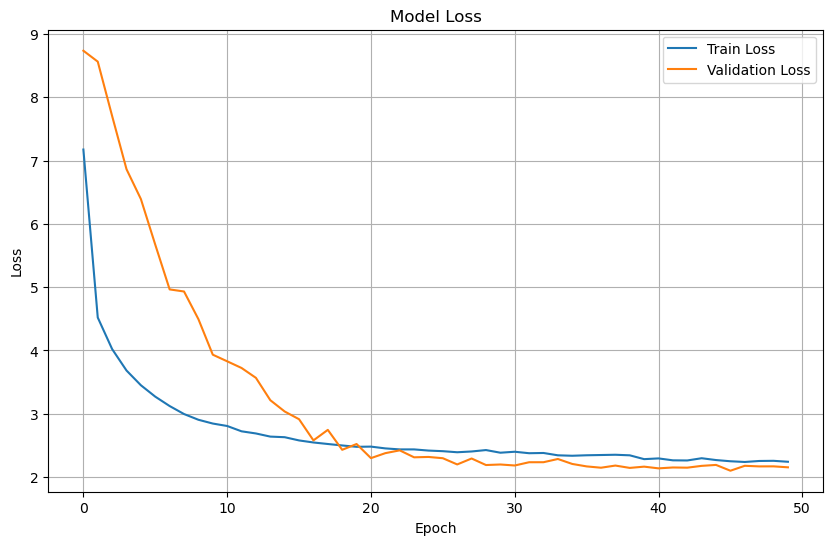

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Prepare test dataset

In [16]:
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(4)

# Evaluate the model on the test dataset
test_loss, test_mae = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.9907 - masked_mae: 0.9796
Test Loss: 0.9896196126937866
Test MAE: 0.9232749938964844


## Make some maps of our predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


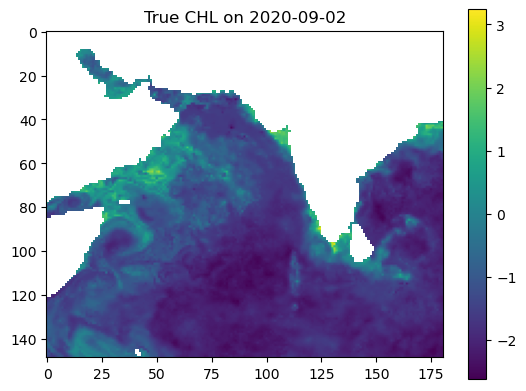

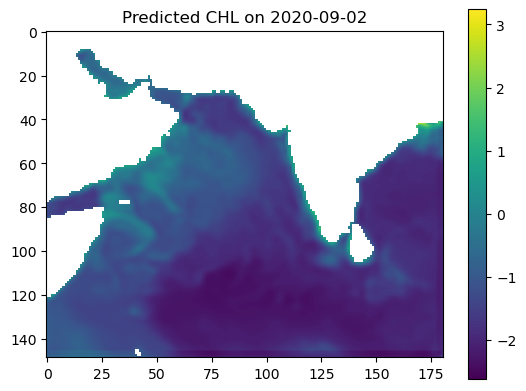

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Example: date to predict
date_to_predict = np.datetime64("2020-09-02")

# Get index of that date
available_times = data_xr["time"].values
date_index = np.where(available_times == date_to_predict)[0][0]

# Prepare input (X: shape = [time, lat, lon, n_features])
input_data = X[date_index]  # shape = (lat, lon, n_features)
input_data = np.array(input_data)     # convert to numpy

# Predict
predicted_output = model.predict(input_data[np.newaxis, ...])[0]
predicted_output = predicted_output[:, :, 0]  # shape = (lat, lon)

# True value from y
true_output = y[date_index]

# Mask land (land_mask = ~ocean)
land_mask = dataset["ocean_mask"].values == 0.0
predicted_output[land_mask] = np.nan
true_output = np.where(land_mask, np.nan, true_output)

# Plot
vmin = np.nanmin([true_output, predicted_output])
vmax = np.nanmax([true_output, predicted_output])

plt.imshow(true_output, vmin=vmin, vmax=vmax, cmap='viridis')
plt.colorbar()
plt.title(f"True CHL on {date_to_predict}")
plt.show()

plt.imshow(predicted_output, vmin=vmin, vmax=vmax, cmap='viridis')
plt.colorbar()
plt.title(f"Predicted CHL on {date_to_predict}")
plt.show()


### Let's look at all the months

First we will create a function that takes our model, the normalizing `X_mean` and `X_std`, the year to use and then makes plots of true versus predicted.

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

def plot_true_vs_predicted(data, year, model, X_mean, X_std, num_var, cat_var):
    """
    Plot true vs predicted output for first available day of each month in data_test.

    Parameters:
        data (xarray.Dataset): Contains variables 'y', 'ocean_mask', and coords 'lat', 'lon', 'time'
        year (string in format XXXX): The year to use.
        model (tf.keras.Model): Trained model with a .predict() method
        X_mean (np.ndarray): mean from the model training data (num_vars only)
        X_std (np.ndarray): std from the model training data
        num_var (np.ndarry): The variables to be standardized with `X_mean` and `X_std`
        cat_var (np.ndarry): The variables to be included in X, y but not standardized.
    """
    data_test = data.sel(time=year)
    
    # Get available time points and group by month
    available_dates = pd.to_datetime(data_test.time.values)
    monthly_dates = (
        pd.Series(available_dates)
        .groupby([available_dates.year, available_dates.month])
        .min()
        .sort_values()
    )
    n_months = len(monthly_dates)

    # lat/lon info
    lat = data_test.lat.values
    lon = data_test.lon.values
    extent = [lon.min(), lon.max(), lat.min(), lat.max()]
    flip_lat = lat[0] > lat[-1]
    land_mask = data_test["ocean_mask"].values == 0.0

    # only normalize num_var
    num_var = ['sst', 'so'] 
    cat_var = ['ocean_mask', 'sin_time', 'cos_time'] 
    split_ratio = [0.0, 0.0, 1.0]
    X, y, *_ = time_series_split(data_test, num_var, cat_var, split_ratio, X_mean=X_mean, X_std=X_std)

    # Create figure and axes
    fig, axs = plt.subplots(n_months, 2, figsize=(7, 2 * n_months), constrained_layout=True)

    for i, date in enumerate(monthly_dates):
        date_index = np.where(available_dates == date)[0][0]

        # True output
        true_output = data_test['y'].sel(time=date).values
        if flip_lat:
            true_output = np.flipud(true_output)

        # Prediction
        input_data = np.array(X[date_index])
        predicted_output = model.predict(input_data[np.newaxis, ...])[0]
        predicted_output = predicted_output[:, :, 0]
        predicted_output[land_mask] = np.nan
        if flip_lat:
            predicted_output = np.flipud(predicted_output)

        # Shared color scale
        vmin = np.nanpercentile([true_output, predicted_output], 5)
        vmax = np.nanpercentile([true_output, predicted_output], 95)

        # Compute R² and RMSE
        true_flat = true_output.flatten()
        pred_flat = predicted_output.flatten()
        valid_mask = ~np.isnan(true_flat) & ~np.isnan(pred_flat)
        r2 = r2_score(true_flat[valid_mask], pred_flat[valid_mask])
        rmse = np.sqrt(np.mean((true_flat[valid_mask] - pred_flat[valid_mask]) ** 2))

        # Plot true
        axs[i, 0].imshow(true_output, origin='lower', extent=extent,
                         vmin=vmin, vmax=vmax, cmap='viridis',
                         aspect='equal')
        axs[i, 0].set_title(f"{date.strftime('%b')} — True", fontsize=10)
        axs[i, 0].axis('off')

        # Plot predicted
        axs[i, 1].imshow(predicted_output, origin='lower', extent=extent,
                         vmin=vmin, vmax=vmax, cmap='viridis',
                         aspect='equal')
        axs[i, 1].set_title(f"{date.strftime('%b')} — Pred\n$R^2$ = {r2:.2f}, RMSE = {rmse:.2f}", fontsize=10)
        axs[i, 1].axis('off')

    plt.suptitle('CHL: True vs Predicted (log scale) '+year, fontsize=16)
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


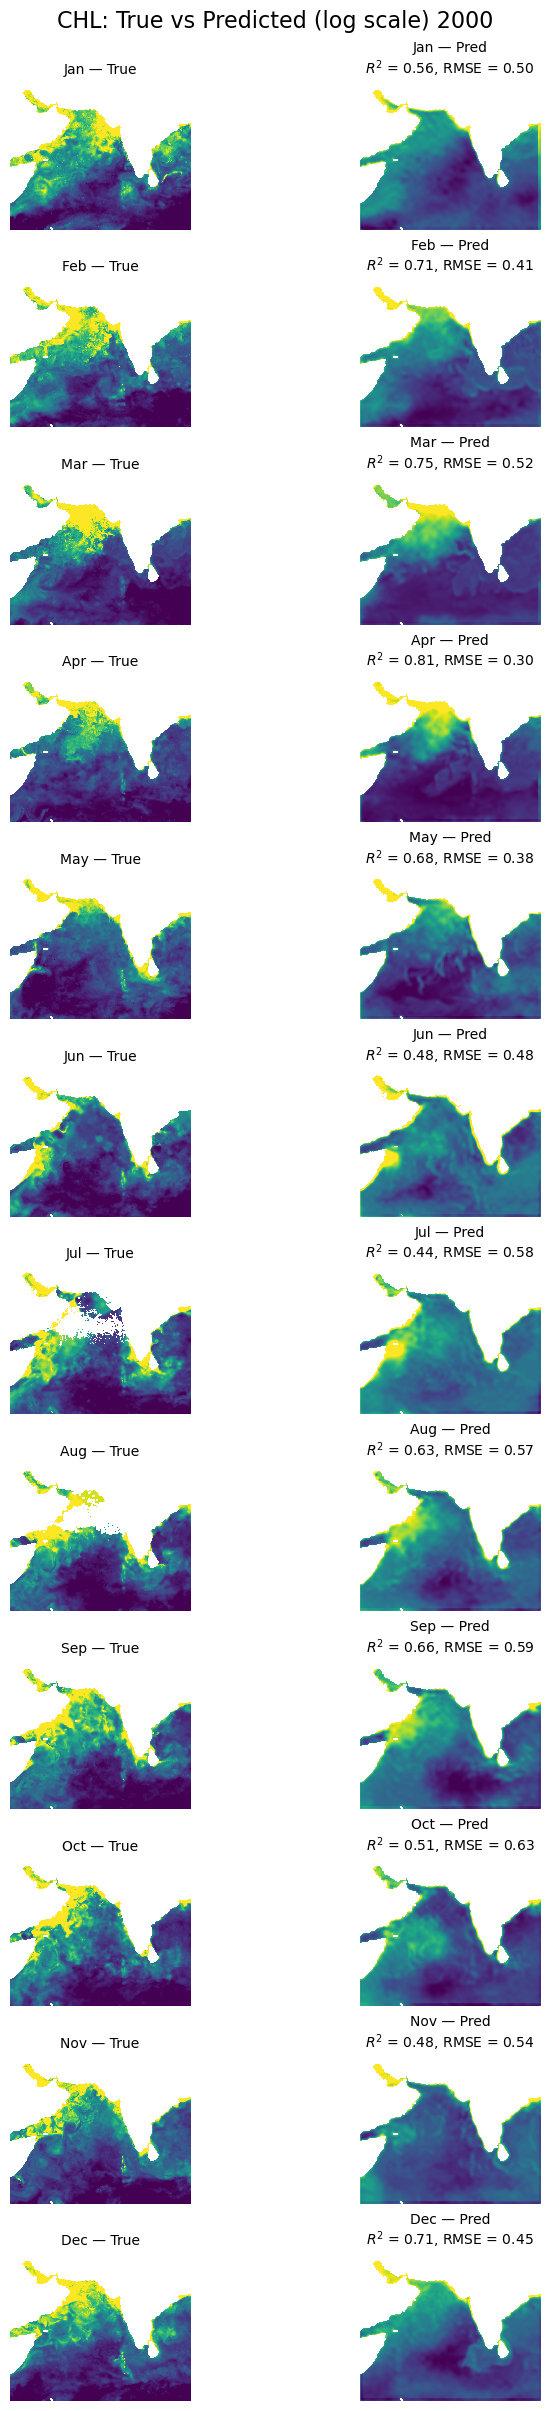

In [37]:
num_var = ['sst', 'so'] 
cat_var = ['ocean_mask', 'sin_time', 'cos_time'] 
plot_true_vs_predicted(dataset, "2000", model, X_mean, X_std, num_var, cat_var)

## Summary

Now we have a model that is doing ok. It still doesn't pick up the upwelling zone at the southern tip of India. There is something about that area that is different and that the model is unable to learn. We should look into what drives that upwelling zone. It maybe that the relationship between SST and salinity are different there. It pokes down into a strong E-W current system.